# Evaluation on Synthetic Cases

# Libraries

In [1]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, BoundaryNorm
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import pandas as pd
import numpy as np
import torch
import cv2
import os

os.chdir('../..')

from wavesim.utils import noise_at_level, crop_centered_window, plot_perturbation, custom_format, SHIFTED_BRBG_COLORS, dataframe_to_markdown_table
from wavesim.metrics import DataStructuralSimilarityIndex, NormalizedRootMeanSquaredError
from wavesim import WaveSim, Wavelet2DBaseTorch
#from wavesim import WaveSim

%load_ext autoreload
%autoreload 2

# Load Precipitation Data

In [2]:
# ground truth / reference
era5_ds = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-1440x721.zarr', consolidated=True, decode_timedelta=True)
#hres_ds = xr.open_zarr('gs://weatherbench2/datasets/hres/2016-2022-0012-1440x721.zarr', consolidated=True, decode_timedelta=True)

In [3]:
ref_day_reanalysis = '2016-01-01T06:00:000000000'
#ref_day_forecasts = '2016-01-01T00:00:000000000'
#lead_time = '1 days 06:00:00'

reanalysis_field = era5_ds.sel(time=ref_day_reanalysis, method='nearest').sortby('latitude').total_precipitation_6hr
#forecast_field = hres_ds.sel(time=ref_day_forecasts, prediction_timedelta=lead_time).total_precipitation_6hr

## Convert precipition from meters to millimeters

In [4]:
reanalysis_field = reanalysis_field * 1000.0
#forecast_field = forecast_field * 1000.0

# 0. Scores DataFrame

In [5]:
spatial_scores = pd.DataFrame(columns=['perturbation_type', 
                               'perturbation_params', 
                               'nrmse', 
                               'dssim', 
                               #'haar_psi', 
                               'wavesim',
                               'wavesim_components',
                               ]).astype({
                                        'perturbation_type': 'str', 
                                        'perturbation_params': 'str',
                                        'nrmse': np.float32,
                                        'dssim': np.float32,
                                        #'haar_psi': np.float32,
                                        'wavesim': np.float32,
                                        'wavesim_components': 'str',
                                        })
                               
temporal_scores = pd.DataFrame(columns=['init_day', 
                               'lead_days', 
                               'current_day',
                               'nrmse',
                               'dssim',
                               'wavesim',
                               'wavesim_components',
                               ]).astype({'init_day': str, 
                                        'lead_days': str, 
                                        'current_day': str,
                                        'nrmse': np.float32,
                                        'dssim': np.float32,
                                        'wavesim': np.float32,
                                        'wavesim_components': 'str',
                               })
                               
spatial_perturbations = {}
temporal_perturbations = {}

# 1. Spatial perturbations

## Cropping across a region in Europe

In [6]:
# centroid coordinates in Europe
center_lon = 10.0
center_lat = 49.75
patch_size = 256
shift_lon_deg = 0.0 # we don't shift here; it's the reference map
shift_lat_deg = 0.0 # we don't shift here; it's the reference map
reference = crop_centered_window(reanalysis_field, 
                                 center_lon = center_lon, 
                                 center_lat = center_lat, 
                                 size_lon = patch_size, 
                                 size_lat = patch_size, 
                                 shift_lon_deg = shift_lon_deg, 
                                 shift_lat_deg = shift_lat_deg)

## Perturbation #1 : spatial shift

In the following implementation of 'crop_centered_window': 
- negative (positive) longitude shifts produce rightward (eastward) visual shifts
- negative (positive) latitude shifts produce northward (southward) visual shifts

Note that ERA5 coordinates are natively expresses in degrees East for longitudes and degrees North for latitude.

### Case 1 : -1 deg longitudes

In [7]:
shift_lon_deg = -1.0
shift_lat_deg = 0.0
shifted_case_1 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_1' : {'perturbation_params' : params, 'values' : shifted_case_1.values}})

Bias min: -14.336565971374512, max: 10.86430549621582


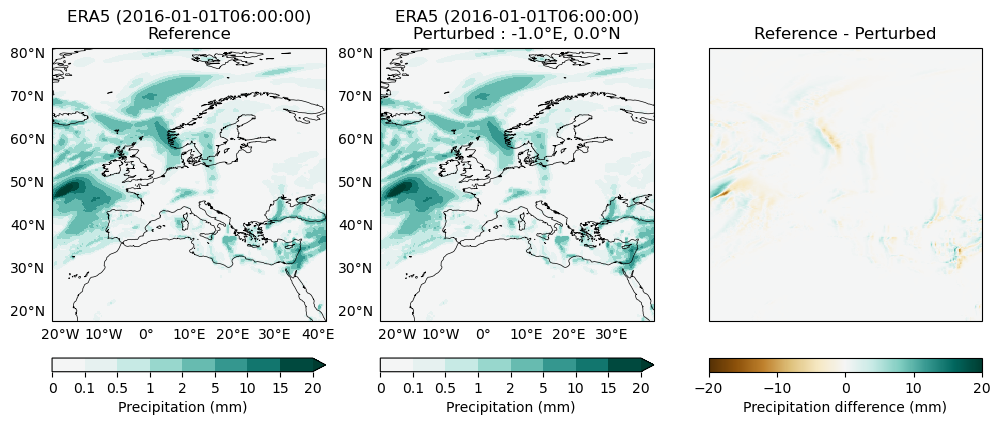

In [8]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
#perturbed_coords = (shifted_case_1.longitude, shifted_case_1.latitude)
perturbed_coords = ((shifted_case_1.longitude + shift_lon_deg), (shifted_case_1.latitude + shift_lat_deg))
plot_perturbation(reference=reference.values, perturbed=shifted_case_1.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 2 : -2 deg longitudes, 0 deg latitude

In [9]:
shift_lon_deg = -2.0
shift_lat_deg = 0.0
shifted_case_2 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_2' : {'perturbation_params' : params, 'values' : shifted_case_2.values}})

Bias min: -18.785533905029297, max: 18.683486938476562


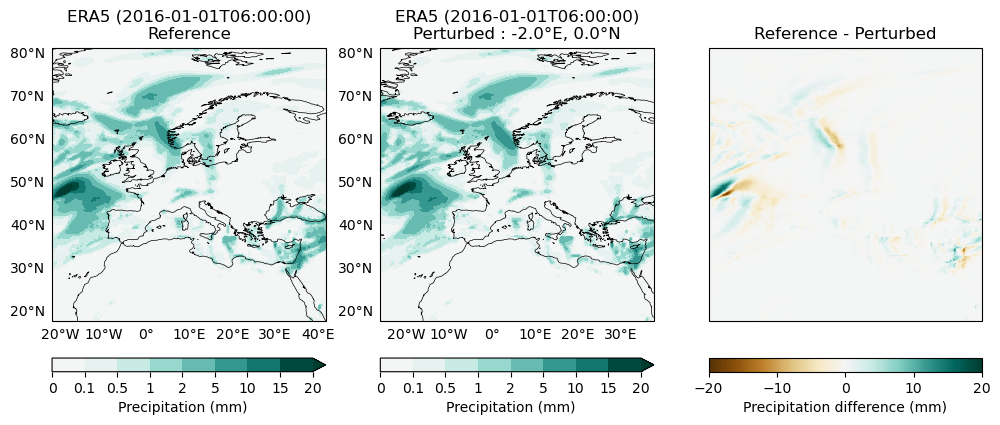

In [10]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
#perturbed_coords = (shifted_case_2.longitude, shifted_case_2.latitude)
perturbed_coords = ((shifted_case_2.longitude + shift_lon_deg), (shifted_case_2.latitude + shift_lat_deg))
plot_perturbation(reference=reference.values, perturbed=shifted_case_2.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 3 : -10 deg longitudes, 0 deg latitudes

In [11]:
shift_lon_deg = -10.0
shift_lat_deg = 0.0
shifted_case_3 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_3' : {'perturbation_params' : params, 'values' : shifted_case_3.values}})

Bias min: -23.107067108154297, max: 26.067569732666016


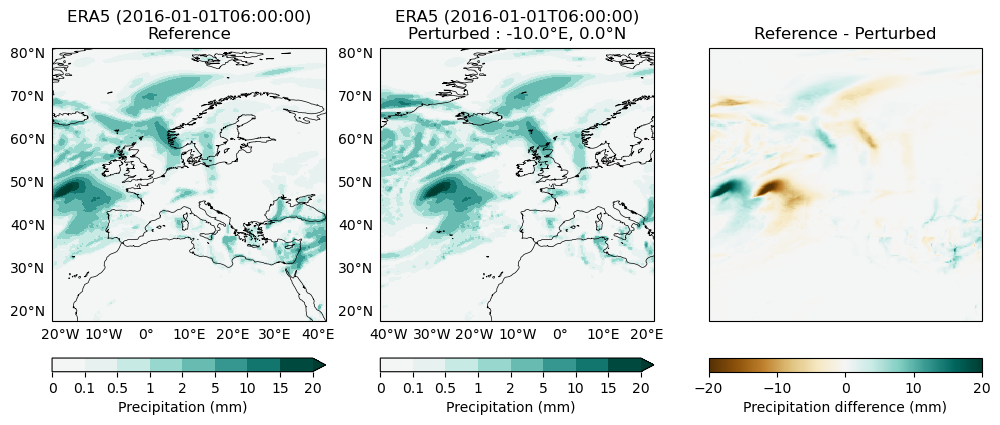

In [12]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
#perturbed_coords = (shifted_case_3.longitude, shifted_case_3.latitude)
perturbed_coords = ((shifted_case_3.longitude + shift_lon_deg), (shifted_case_3.latitude + shift_lat_deg))
plot_perturbation(reference=reference.values, perturbed=shifted_case_3.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 4 : -10 deg longitudes, -10 deg latitude

In [13]:
shift_lon_deg = -10.0
shift_lat_deg = -10.0
shifted_case_4 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_4' : {'perturbation_params' : params, 'values' : shifted_case_4.values}})

Bias min: -26.072547912597656, max: 26.229854583740234


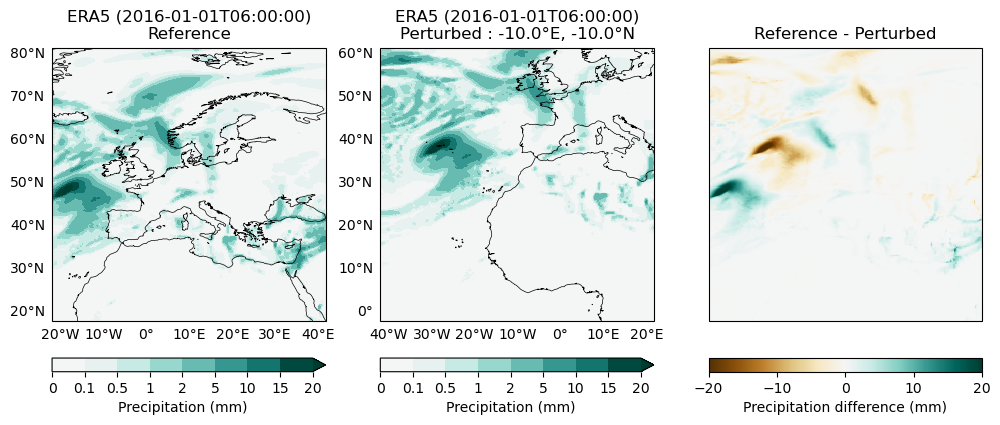

In [14]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
#perturbed_coords = (shifted_case_4.longitude, shifted_case_4.latitude)
perturbed_coords = ((shifted_case_4.longitude + shift_lon_deg), (shifted_case_4.latitude + shift_lat_deg))
plot_perturbation(reference=reference.values, perturbed=shifted_case_4.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 5 : -40 deg longitudes, -60 deg latitude

In [15]:
shift_lon_deg = -30#-40.0
shift_lat_deg = -50#-60.0
shifted_case_5 = crop_centered_window(reanalysis_field, center_lon = 10.0, center_lat = 49.75, size_lon=256, size_lat=256, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)
params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_5' : {'perturbation_params' : params, 'values' : shifted_case_5.values}})

Bias min: -75.67182159423828, max: 25.34026336669922


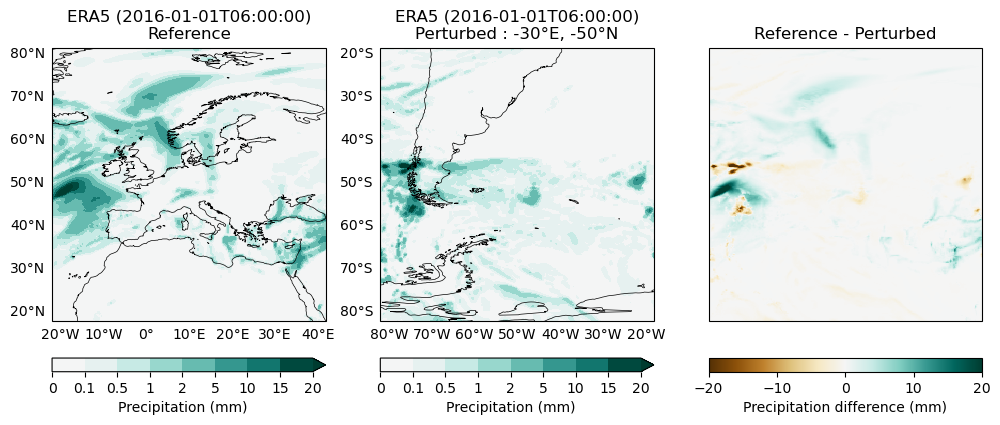

In [16]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
#perturbed_coords = (shifted_case_5.longitude, shifted_case_5.latitude)
perturbed_coords = ((shifted_case_5.longitude + shift_lon_deg), (shifted_case_5.latitude + shift_lat_deg))
plot_perturbation(reference=reference.values, perturbed=shifted_case_5.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

## Perturbation #2 : flip

### Case 1 : Horizontal flip

In [17]:
flip_case_1 = np.fliplr(reference.copy().values)
params = {'flip' : 'horizontal'}
spatial_perturbations.update({'flip_case_1' : {'perturbation_params' : params, 'values' : flip_case_1}})

Bias min: -26.38368034362793, max: 26.38368034362793


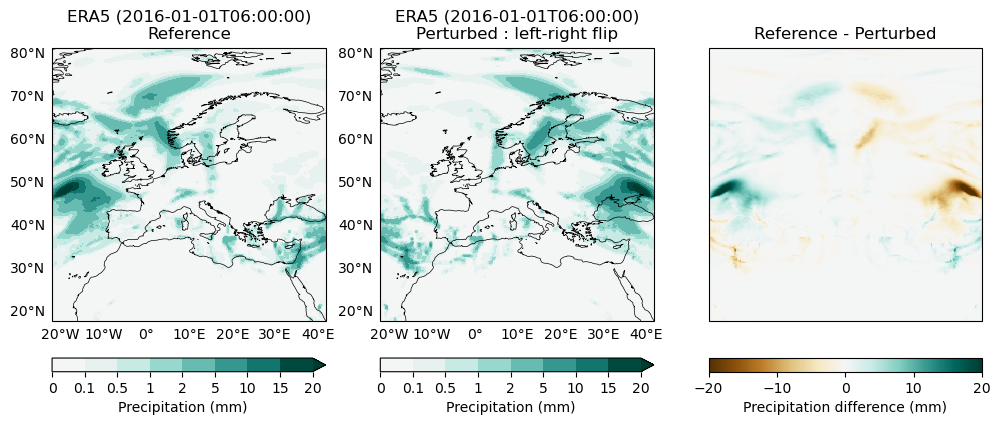

In [18]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : left-right flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_1, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 2 : Vertical flip

In [19]:
flip_case_2 = np.flipud(reference.copy().values)
params = {'flip' : 'vertical'}
spatial_perturbations.update({'flip_case_2' : {'perturbation_params' : params, 'values' : flip_case_2}})

Bias min: -25.250160217285156, max: 25.250160217285156


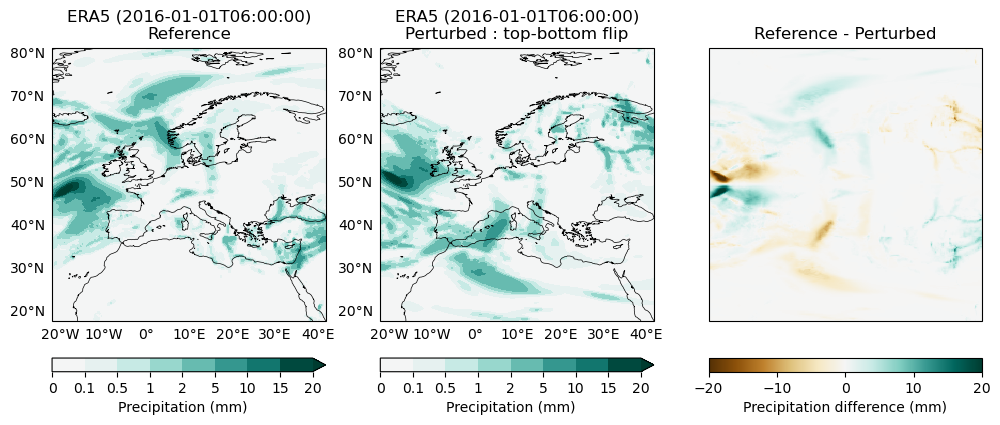

In [20]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : top-bottom flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_2, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 3 : diagonal flip

In [21]:
flip_case_3 = reference.copy().values.T
params = {'flip' : 'diagonal'}
spatial_perturbations.update({'flip_case_3' : {'perturbation_params' : params, 'values' : flip_case_3}})

Bias min: -26.3896484375, max: 26.3896484375


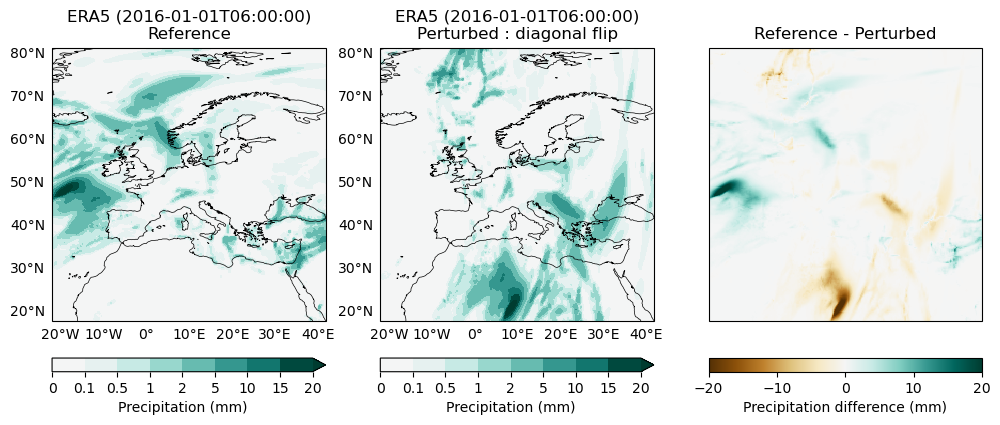

In [22]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : diagonal flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_3, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

## Perturbation #3 : spatial upscaling

### Case 1 : scale factor : 0.5

In [23]:
scale_factor = 0.5
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_1 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_1' : {'perturbation_params' : params, 'values' : upscale_case_1}})

Bias min: -5.43862247467041, max: 10.817513465881348


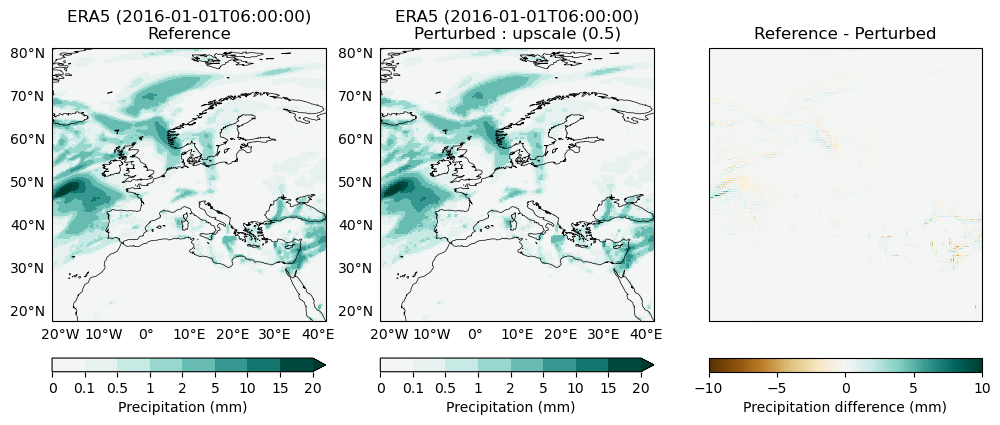

In [24]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_1, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim = 10)

### Case 2 : scale factor 0.3

In [25]:
scale_factor = 0.3
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_2 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_2' : {'perturbation_params' : params, 'values' : upscale_case_2}})

Bias min: -8.757058143615723, max: 17.644546508789062


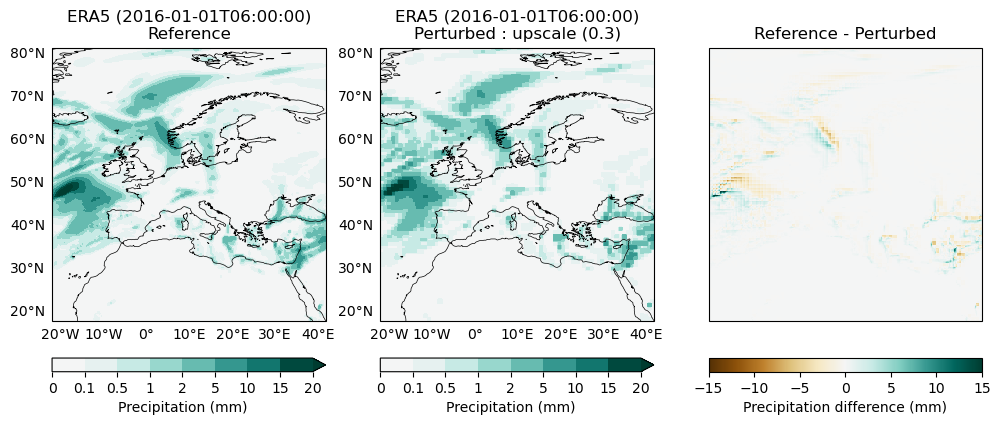

In [26]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_2, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim = 15)

### Case 3 : scale factor 0.1

In [27]:
scale_factor = 0.1
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_3 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_3' : {'perturbation_params' : params, 'values' : upscale_case_3}})

Bias min: -21.880451202392578, max: 23.590444564819336


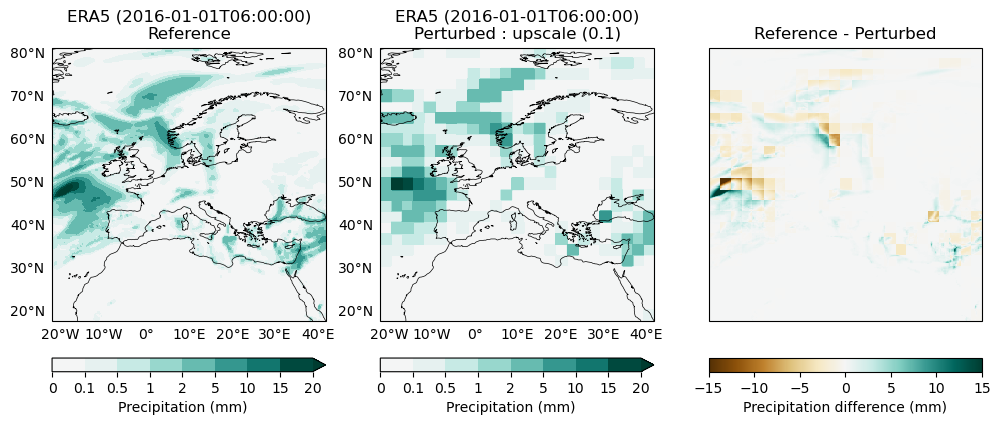

In [28]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_3, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim = 15)

## Perturbation #4 : noise on different scales

### Case 1 : noise on approximation coefficients

In [29]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\nlarge scale (approx)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -3.833970308303833, max: 4.48045015335083


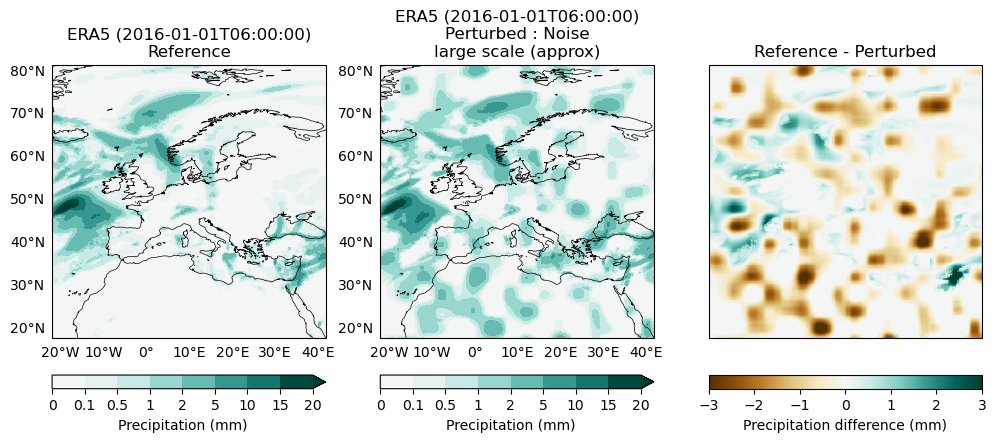

In [30]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_1 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=-1, orientation=None, rand_state=32)
spatial_perturbations.update({'noise_case_1' : {'perturbation_params' : None, 'values' : noise_case_1}})
plot_perturbation(reference=reference.values, perturbed=noise_case_1, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim = 3)

### Case 2 : noise on detail level 1 - horizontal orientation

In [31]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\nhorizontal details (level 1)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -0.3889044523239136, max: 0.38970646262168884


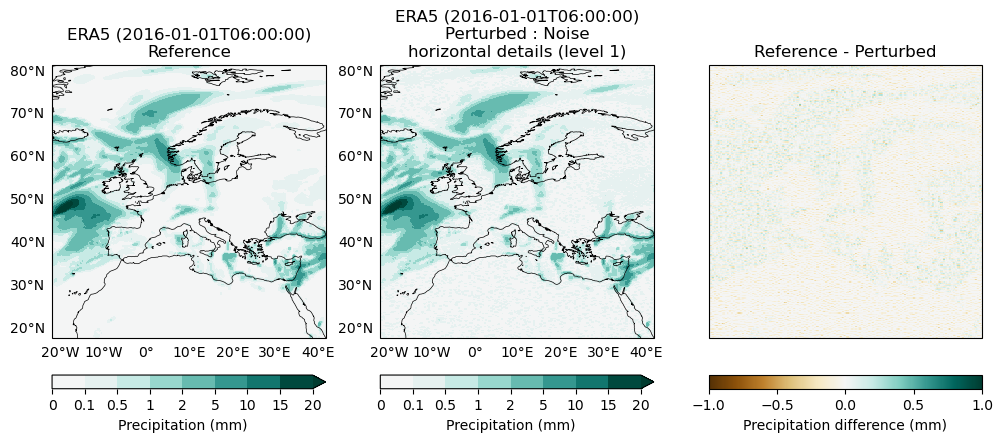

In [32]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_2 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=1, orientation='H', rand_state=32)
spatial_perturbations.update({'noise_case_2' : {'perturbation_params' : None, 'values' : noise_case_2}})
plot_perturbation(reference=reference.values, perturbed=noise_case_2, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim=1)

### Case 3 : noise on detail level 2 - vertical orientation

In [33]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\nvertical details (level 2)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -0.42631563544273376, max: 0.36236637830734253


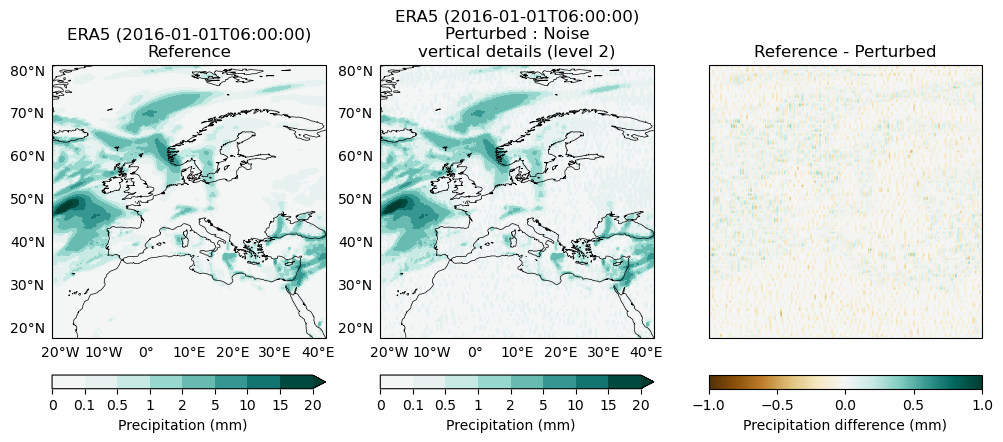

In [34]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_3 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=2, orientation='V', rand_state=32)
spatial_perturbations.update({'noise_case_3' : {'perturbation_params' : None, 'values' : noise_case_3}})
plot_perturbation(reference=reference.values, perturbed=noise_case_3, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim=1)

### Case 4 : noise on detail level 3 - diagonal orientation

In [35]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\ndiagonal details (level 3)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -0.7176268696784973, max: 0.800534725189209


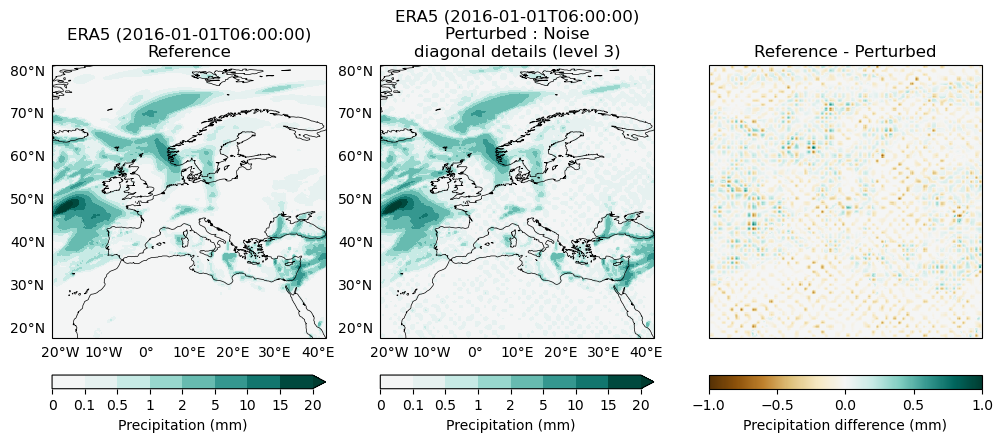

In [36]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_4 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=3, orientation='D', rand_state=32)
spatial_perturbations.update({'noise_case_4' : {'perturbation_params' : None, 'values' : noise_case_4}})
plot_perturbation(reference=reference.values, perturbed=noise_case_4, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim=1)

### Case 5 : noise on detail level 4 - horizontal orientation

In [37]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\nhorizontal details (level 4)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -1.347221851348877, max: 1.4589111804962158


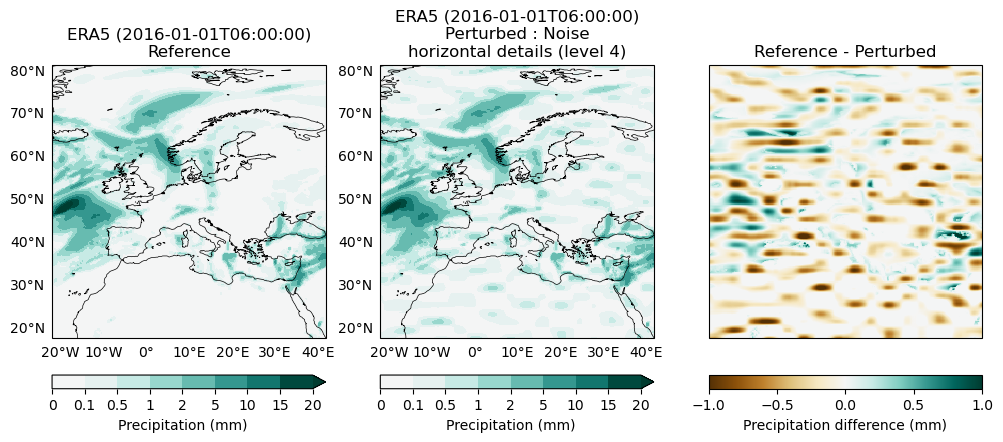

In [38]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_5 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=4, orientation='H', rand_state=32)
spatial_perturbations.update({'noise_case_5' : {'perturbation_params' : None, 'values' : noise_case_5}})
plot_perturbation(reference=reference.values, perturbed=noise_case_5, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim=1)

## Benchmark spatial perturbations

In [39]:
wavesim_params = {'wavelet': 'db4',
                'mode': 'zero',  ## 'zero', 'symmetric', 'reflect' or 'periodization'
                'levels': 4,
                'operation': 'sum',
                'components_weight': {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.0},
                #'scales_weight': [0.2, 0.2, 0.2, 0.2, 0.2] # TODO : transform in a tensor (B, C, L+1)
                'scales_weight': [0.25, 0.25, 0.25, 0.25],
                'use_approx': False,
                }

dssim_params = {'C1' : 1.0e-8, 
                'C2' : 1.0e-8, 
                'k' : 5, 
                'std' : 1.5, 
                'ksize' : 11,  
                'discretize' : True,
                'return_contrast' : False}

nrsme_params = {'mode' : 'range'}

In [40]:
for perturbation_type, perturbation_dict in spatial_perturbations.items():
    print(f'Processing {perturbation_type}...')
    params, data = perturbation_dict['perturbation_params'], perturbation_dict['values']
    
    # Normalized Root Mean Squared Error
    nrmse_score = NormalizedRootMeanSquaredError(map1=reference.copy(), map2=data.copy(), params=nrsme_params).compute()
    
    # Data Structural Similarity Index Measure
    dssim_score = DataStructuralSimilarityIndex(map1=reference.copy(), map2=data.copy(), params=dssim_params).compute()
    
    # wavesim
    wavesim = WaveSim(map1=reference.copy(), map2=data.copy(), params=wavesim_params)
    
    if perturbation_type == 'flip_case_3':
        wavesim_displacement = wavesim
    
    wavesim_score = wavesim.compute()
    wavesim_components = {'magnitude': wavesim.magnitude_sim_score.numpy().ravel(),
                          'displacement': wavesim.displacement_sim_score.numpy().ravel(), 
                          'structural' : wavesim.structural_sim_score.numpy().ravel()
                          }
    
    new_row = pd.DataFrame({'perturbation_type' : [perturbation_type],
                                'perturbation_params' : [params], 
                                'nrmse' : [nrmse_score],
                                'dssim' : [dssim_score],
                                'wavesim' : [wavesim_score],
                                'wavesim_components' : [wavesim_components]
                                })
    
    spatial_scores = pd.concat([spatial_scores, new_row], ignore_index=True)

Processing shifted_case_1...
Processing shifted_case_2...
Processing shifted_case_3...
Processing shifted_case_4...
Processing shifted_case_5...
Processing flip_case_1...
Processing flip_case_2...
Processing flip_case_3...
Processing upscale_case_1...
Processing upscale_case_2...
Processing upscale_case_3...
Processing noise_case_1...
Processing noise_case_2...
Processing noise_case_3...
Processing noise_case_4...


KeyboardInterrupt: 

In [ ]:
spatial_scores.to_csv('./examples/case_studies/synthetic_cases_spatial_scores.csv', index=False)

In [ ]:
dataframe_to_markdown_table(spatial_scores, 'examples/case_studies/synthetic_cases_spatial_scores.md')

In [ ]:
"""
case = 'upscale_case_1'

print(f'wavesim : {spatial_scores[spatial_scores['perturbation_type'] == case]['wavesim'].values[0]}')
print(f'magnitude : {spatial_scores[spatial_scores['perturbation_type'] == case]['wavesim_components'].values[0]['magnitude']}')
print(f'structural : {spatial_scores[spatial_scores['perturbation_type'] == case]['wavesim_components'].values[0]['structural']}')
print(f'displacement : {spatial_scores[spatial_scores['perturbation_type'] == case]['wavesim_components'].values[0]['displacement']}')
"""

# 2. Temporal perturbations

In [ ]:
# Spatial Domain of interest
# centroid coordinates in Europe
center_lon = 10.0
center_lat = 49.75
patch_size = 256
shift_lon_deg = 0.0 # we don't shift here
shift_lat_deg = 0.0 # we don't shift here

## Benchmark temporal perturbations

In [ ]:
wavesim_temporal_params = {'wavelet': 'db4',
                'mode': 'zero',
                'levels': 4,
                'operation': 'sum',
                'components_weight': {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.0},
                #'scales_weight': [0.2, 0.2, 0.2, 0.2, 0.2], # TODO : transform in a tensor (B, C, L+1)
                'scales_weight': [0.25, 0.25, 0.25, 0.25],
                'use_approx': False,
                }

In [ ]:
year = '2016'
month = '01'
init_day = 1
hour = '06:00:000000000'

init_day_reanalysis = f'{year}-{month}-{init_day}T{hour}'
init_day_reanalysis_field = era5_ds.sel(time=init_day_reanalysis, method='nearest').sortby('latitude').total_precipitation_6hr * 1000.0
init_day_cropped = crop_centered_window(init_day_reanalysis_field, center_lon=center_lon, center_lat=center_lat, size_lon=patch_size, size_lat=patch_size, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)
init_day_data = np.where(init_day_cropped.values < 0.0, 0.0, init_day_cropped.values)

##ref_day_reanalysis = f'{year}-{month}-{init_day:02d}T{hour}'

wavesim_instances = []
for day in np.arange(1, 10):
    ##ref_day_reanalysis = f'{year}-{month}-{init_day + day:02d}T{hour}'
    ##print(f'Reanalysis : {ref_day_reanalysis[:-7]}')
    lead_days = f'{day} days 06:00:00'
    current_day = f'{year}-{month}-{init_day + day:02d}T{hour}'
    ##print(f'Forecast   : {ref_day_forecasts[:-7]} + {lead_time}')
    print(f'lead day : {init_day_reanalysis[:-7]} + {lead_days} : {current_day[:-7]}')
    #print(f'lead day : {lead_day}')

    lead_day_reanalysis_field = era5_ds.sel(time=current_day, method='nearest').sortby('latitude').total_precipitation_6hr
    ##reanalysis_field = era5_ds.sel(time=ref_day_reanalysis, method='nearest').sortby('latitude').total_precipitation_6hr
    ##forecast_field = hres_ds.sel(time=ref_day_forecasts, prediction_timedelta=lead_time).total_precipitation_6hr
    
    lead_day_reanalysis_field = lead_day_reanalysis_field * 1000.0
    ##reanalysis_field = reanalysis_field * 1000.0
    ##forecast_field = forecast_field * 1000.0

    lead_day_cropped = crop_centered_window(lead_day_reanalysis_field, center_lon=center_lon, center_lat=center_lat, size_lon=patch_size, size_lat=patch_size, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)
    ##reference_cropped = crop_centered_window(reanalysis_field, center_lon=center_lon, center_lat=center_lat, size_lon=patch_size, size_lat=patch_size, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)
    ##forecast_cropped = crop_centered_window(forecast_field, center_lon=center_lon, center_lat=center_lat, size_lon=patch_size, size_lat=patch_size, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)

    # clean negative values in precipitation fields
    
    lead_day_data = np.where(lead_day_cropped.values < 0.0, 0.0, lead_day_cropped.values)
    ##reference_data = np.where(reference_cropped.values < 0.0, 0.0, reference_cropped.values)
    ##forecast_data = np.where(forecast_cropped.values < 0.0, 0.0, forecast_cropped.values)

    ##wavesim_temp = WaveSim(map1=reference_data.copy(), map2=forecast_data.copy(), params=wavesim_temporal_params)
    wavesim_temp = WaveSim(map1=init_day_data.copy(), map2=lead_day_data.copy(), params=wavesim_temporal_params)
    wavesim_temp_score = wavesim_temp.compute()
    wavesim_instances.append(wavesim_temp)
    wavesim_temp_components = {'magnitude': wavesim_temp.magnitude_sim_score.numpy().ravel(),
                             'displacement': wavesim_temp.displacement_sim_score.numpy().ravel(), 
                             'structural' : wavesim_temp.structural_sim_score.numpy().ravel(), 
                            }

    ##nrmse_score = NormalizedRootMeanSquaredError(map1=reference_data, map2=forecast_data, params=nrsme_params).compute()
    ##dssim_score = DataStructuralSimilarityIndex(map1=reference_data, map2=forecast_data, params=dssim_params).compute()
    
    nrmse_score = NormalizedRootMeanSquaredError(map1=init_day_data.copy(), map2=lead_day_data.copy(), params=nrsme_params).compute()
    dssim_score = DataStructuralSimilarityIndex(map1=init_day_data.copy(), map2=lead_day_data.copy(), params=dssim_params).compute()

    ##new_row = pd.DataFrame({'forecast init' : [ref_day_forecasts[:-7]], 
    new_row = pd.DataFrame({'init_day' : [init_day_reanalysis[:-7]],#[lead_day[:-7]], 
                                'lead_days' : [lead_days],
                                ##'reanalysis' : [ref_day_reanalysis[:-7]],
                                'current_day' : [current_day[:-7]],
                                'nrmse' : [nrmse_score],
                                'dssim' : [dssim_score],
                                'wavesim' : [wavesim_temp_score],
                                'wavesim_components' : [wavesim_temp_components],
                                })

    temporal_perturbations[f'Reference + {lead_days}'] = lead_day_data.copy()
    temporal_scores = pd.concat([temporal_scores, new_row], ignore_index=True)

In [ ]:
temporal_scores.to_csv('examples/case_studies/synthetic_cases_temporal_scores.csv', index=False)

In [ ]:
dataframe_to_markdown_table(temporal_scores, 'examples/case_studies/synthetic_cases_temporal_scores.md')

# Plot : Figure 2 of the Paper

In [ ]:
perturbations = {'ERA5 2016-01-01 06h (Reference)' : reference.values,
                 'Shift +1°E, 0°N' : shifted_case_1, 
                 'Shift +10°E, +10°N' : shifted_case_4, 
                 'Shift +40°E, +60°N' : shifted_case_5, 
                 'Horizontal + Vertical flips' : flip_case_3, 
                 'Upscale (scale factor 0.5)' : upscale_case_1} 

lead_days = [1, 2, 3]

for lead in lead_days:
    perturbations['Reference + ' + f'{lead} days 06h'] = temporal_perturbations[f'Reference + {lead} days 06:00:00']

In [ ]:
"""# centroid coordinates in Europe
center_lon = 10.0
center_lat = 49.75
patch_size = 256
shift_lon_deg = 0.0 # we don't shift here
shift_lat_deg = 0.0 # we don't shift here

year = '2016'
month = '01'
##init_day = 1
init_day = 2
hour = '06:00:000000000'
lead_days = [1, 3, 7]

for day in lead_days:
    lead_time = f'{day} days 06:00:00'
    ref_day_reanalysis = f'{year}-{month}-{init_day + day:02d}T{hour}'
    print(f'Reanalysis : {ref_day_reanalysis[:-7]}')
    print(f'Forecast   : {ref_day_forecasts[:-7]} + {lead_time}')
    
    reanalysis_lead_field = era5_ds.sel(time=ref_day_reanalysis, method='nearest').sortby('latitude').total_precipitation_6hr

    ##reanalysis_field = era5_ds.sel(time=ref_day_reanalysis, method='nearest').sortby('latitude').total_precipitation_6hr * 1000.0
    ##forecast_field = hres_ds.sel(time=ref_day_forecasts, prediction_timedelta=lead_time).total_precipitation_6hr * 1000.0

    ##reference_cropped = crop_centered_window(reanalysis_field, center_lon=center_lon, center_lat=center_lat, size_lon=patch_size, size_lat=patch_size, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)
    ##forecast_cropped = crop_centered_window(forecast_field, center_lon=center_lon, center_lat=center_lat, size_lon=patch_size, size_lat=patch_size, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)

    ##reference_cropped = np.where(reference_cropped.values < 0.0, 0.0, reference_cropped.values)
    ##forecast_cropped = np.where(forecast_cropped.values < 0.0, 0.0, forecast_cropped.values)

    ##bias = forecast_cropped #- reference_cropped
    #perturbations[f'(HRES - ERA5) {year}-{month}-{init_day + day:02d}T{hour[:8]}'] = bias
    ##perturbations[f'HRES {year}-{month}-{init_day + day:02d} {hour[:2]}h'] = bias
    #print(f'HRES {year}-{month}-{init_day + day:02d}T{hour[:8]}')"""

In [ ]:
"""plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'  # or 'serif', 'sans-serif', 'monospace', etc

gridline_settings = {'draw_labels': True, 'linewidth': 0.0, 'color': 'gray', 'alpha': 0.5, 'linestyle': '--'}

fig, axs = plt.subplots(3, 3, figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})
#plt.subplots_adjust(wspace=0.08, hspace=0.08)


ims = []
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']
for i, ax in enumerate(axs.ravel()):

    label = list(perturbations.keys())[i]
    data = perturbations[label]

    if i == 3:
        lon, lat = shifted_case_5.longitude, shifted_case_5.latitude
    else:
        lon, lat = reference.longitude, reference.latitude

    lon_grid, lat_grid = np.meshgrid(lon, lat)
    domain_extent = [lon.min(), lon.max(), lat.min(), lat.max()]
    ax.set_extent(domain_extent, crs=ccrs.PlateCarree())

    if i in [6,7,8]:
        color_levels = [0.0, 0.1, 0.5, 1, 2, 5, 10, 15, 20]
        cmap = ListedColormap(SHIFTED_BRBG_COLORS)
        norm = BoundaryNorm(list(color_levels), ncolors=len(color_levels))
        im = ax.contourf(lon_grid, lat_grid, data, levels=color_levels, cmap=cmap, norm=norm, extend='max', transform=ccrs.PlateCarree())
    else: 
        color_levels = [0.0, 0.1, 0.5, 1, 2, 5, 10, 15, 20]
        cmap = ListedColormap(SHIFTED_BRBG_COLORS)
        norm = BoundaryNorm(list(color_levels), ncolors=len(color_levels))
        formatter = FuncFormatter(custom_format)
        
        im = ax.contourf(lon_grid, lat_grid, data, levels=color_levels, cmap=cmap, norm=norm, extend='max', transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5, zorder=2)
    # letters for panels
    ax.annotate(f"$\\mathbf{{({panel_labels[i]})}}$",
            xy=(-0.15, 1.04),  # Top-left inside each panel
            xycoords='axes fraction',
            fontsize=14,
            bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", linewidth=0))
    ax.set_title(label, fontsize=14, fontweight='bold')
    gl = ax.gridlines(**gridline_settings)
    gl.top_labels = False
    gl.right_labels = False
    ims.append(im)

# Add one colorbar per row, outside the row
for row in range(3):
    im = ims[row * 3]
    ax_row = axs[row, :]
    if row == 2:
        cbar = fig.colorbar(im, ax=ax_row.tolist(), orientation='vertical', fraction=0.014, pad=0.02, format=formatter)
        cbar.set_label(f'Precipitation (mm/6h)', fontsize=12)
    else:
        cbar = fig.colorbar(im, ax=ax_row.tolist(), orientation='vertical', fraction=0.014, pad=0.02, format=formatter)
        cbar.set_label(f'Precipitation (mm/6h)', fontsize=12)
        cbar.set_ticks(color_levels)

plt.show()
#plt.savefig('figures/fig2.png', dpi=300, bbox_inches='tight')"""

In [ ]:
perturbations.keys()

In [ ]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'  # or 'serif', 'sans-serif', 'monospace', etc

gridline_settings = {'draw_labels': True, 'linewidth': 0.0, 'color': 'gray', 'alpha': 0.5, 'linestyle': '--'}

# Create figure with more space for titles
fig = plt.figure(figsize=(12, 14))

# Create a single GridSpec for the entire layout
# 5 rows: title1, row1, row2, title2, row3
# 3 columns for consistent panel widths
gs = fig.add_gridspec(5, 3, 
                     left=0.06, right=0.94, 
                     top=0.95, bottom=0.08,
                     wspace=0.22, hspace=0.15,
                     height_ratios=[0.04, 1, 1, 0.04, 1])  # title, data, data, title, data

# Add titles
# Title for first section (spans all 3 columns of row 0)
title1_ax = fig.add_subplot(gs[0, :])
title1_ax.text(0.5, 0.5, 'Spatial perturbations', fontsize=18, fontweight='bold', 
               ha='center', va='center', transform=title1_ax.transAxes)
title1_ax.axis('off')

# Title for second section (spans all 3 columns of row 3)
title2_ax = fig.add_subplot(gs[3, :])
title2_ax.text(0.5, 0.5, 'Temporal perturbations', fontsize=18, fontweight='bold',
               ha='center', va='center', transform=title2_ax.transAxes)
title2_ax.axis('off')

ims = []
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']
all_axes = []

# Create axes for all 9 panels
for i in range(9):
    if i < 3:  # First row (a, b, c) - row 1 of GridSpec
        ax = fig.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
    elif i < 6:  # Second row (d, e, f) - row 2 of GridSpec
        ax = fig.add_subplot(gs[2, i-3], projection=ccrs.PlateCarree())
    else:  # Third row (g, h, i) - row 4 of GridSpec
        ax = fig.add_subplot(gs[4, i-6], projection=ccrs.PlateCarree())
    
    all_axes.append(ax)

# Plot data on all panels
for i, ax in enumerate(all_axes):
    label = list(perturbations.keys())[i]
    data = perturbations[label]

    if i == 3:
        lon, lat = shifted_case_5.longitude, shifted_case_5.latitude
    else:
        lon, lat = reference.longitude, reference.latitude

    lon_grid, lat_grid = np.meshgrid(lon, lat)
    domain_extent = [lon.min(), lon.max(), lat.min(), lat.max()]
    ax.set_extent(domain_extent, crs=ccrs.PlateCarree())

    if i in [6, 7, 8]:
        color_levels = [0.0, 0.1, 0.5, 1, 2, 5, 10, 15, 20]
        cmap = ListedColormap(SHIFTED_BRBG_COLORS)
        norm = BoundaryNorm(list(color_levels), ncolors=len(color_levels))
        im = ax.contourf(lon_grid, lat_grid, data, levels=color_levels, cmap=cmap, norm=norm, extend='max', transform=ccrs.PlateCarree())
    else: 
        color_levels = [0.0, 0.1, 0.5, 1, 2, 5, 10, 15, 20]
        cmap = ListedColormap(SHIFTED_BRBG_COLORS)
        norm = BoundaryNorm(list(color_levels), ncolors=len(color_levels))
        formatter = FuncFormatter(custom_format)
        
        im = ax.contourf(lon_grid, lat_grid, data, levels=color_levels, cmap=cmap, norm=norm, extend='max', transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5, zorder=2)
    
    # Panel letters
    ax.annotate(f"$\\mathbf{{({panel_labels[i]})}}$",
            xy=(-0.15, 1.04),  # Top-left inside each panel
            xycoords='axes fraction',
            fontsize=14,
            bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", linewidth=0))
    ax.set_title(label, fontsize=14, fontweight='bold')
    gl = ax.gridlines(**gridline_settings)
    gl.top_labels = False
    gl.right_labels = False
    ims.append(im)

# Add colorbars for each row
# Colorbar for first row (panels a-c)
cbar1 = fig.colorbar(ims[0], ax=all_axes[0:3], orientation='vertical', 
                     fraction=0.014, pad=0.02, format=formatter)
cbar1.set_label(f'Precipitation (mm/6h)', fontsize=12)
cbar1.set_ticks(color_levels)

# Colorbar for second row (panels d-f)
cbar2 = fig.colorbar(ims[3], ax=all_axes[3:6], orientation='vertical', 
                     fraction=0.014, pad=0.02, format=formatter)
cbar2.set_label(f'Precipitation (mm/6h)', fontsize=12)
cbar2.set_ticks(color_levels)

# Colorbar for third row (panels g-i)
cbar3 = fig.colorbar(ims[6], ax=all_axes[6:9], orientation='vertical', 
                     fraction=0.014, pad=0.02, format=formatter)
cbar3.set_label(f'Precipitation (mm/6h)', fontsize=12)
cbar3.set_ticks(color_levels)

#plt.show()
plt.savefig('figures/fig2X.png', dpi=300, bbox_inches='tight')

# **TODO** Plot : Figure SX of the Paper

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import ScalarFormatter
import matplotlib.cm as cm
import numpy as np
import warnings

plt.rcParams['text.usetex'] = True

warnings.filterwarnings("ignore")

n_panels = 5

scales_km = [50, 100, 200, 360, 360]
scales_coeff = ['detail', 'detail', 'detail', 'detail', 'approx']

cmap = cm.BrBG

####
# Get the original BrBG colormap
original_cmap = plt.get_cmap('BrBG')

# Sample 256 values from the original colormap
n_colors = 256
colors = original_cmap(np.linspace(0, 1, n_colors))

# Identify midpoint (assumes symmetric colormap)
midpoint = n_colors // 2

# Replace the midpoint with white
colors[midpoint] = [1.0, 1.0, 1.0, 1.0]  # RGBA white

# Create new colormap
new_cmap = LinearSegmentedColormap.from_list("BrBG_white0", colors)
####

alpha = 0.2

# Figure with outer grid for each panel
fig = plt.figure(figsize=(7 * n_panels, 7), constrained_layout=False)
#plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # reserve room for colorbars

outer = gridspec.GridSpec(1, n_panels, wspace=0.2)

for i in range(n_panels):
    # Create inner grid for each panel
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer[i],
        #width_ratios=[5, 2], height_ratios=[2, 5],
        width_ratios=[4, 1], height_ratios=[1, 4],
        wspace=0.05, hspace=0.05
    )

    # compute spectrum min and max for y-axis bounds
    spectrum_lat_min = min(np.min(wavesim_displacement.m1_marginal_lat[0,0,:,:].numpy()), np.min(wavesim_displacement.m2_marginal_lat[0,0,:,:].numpy()))
    spectrum_lat_max = max(np.max(wavesim_displacement.m1_marginal_lat[0,0,:,:].numpy()), np.max(wavesim_displacement.m2_marginal_lat[0,0,:,:].numpy()))
    spectrum_lon_min = min(np.min(wavesim_displacement.m1_marginal_lon[0,0,:,:].numpy()), np.min(wavesim_displacement.m2_marginal_lon[0,0,:,:].numpy()))
    spectrum_lon_max = max(np.max(wavesim_displacement.m1_marginal_lon[0,0,:,:].numpy()), np.max(wavesim_displacement.m2_marginal_lon[0,0,:,:].numpy()))

    # Subplot axes
    ax_main = fig.add_subplot(inner_gs[1, 0], projection=ccrs.PlateCarree())
    #ax_top = fig.add_subplot(inner_gs[0, 0]) #, sharex=ax_main)
    #ax_right = fig.add_subplot(inner_gs[1, 1]) #, sharey=ax_main)

    # Top marginal (longitude)
    ax_top = inset_axes(ax_main, width="100%", height="100%", loc='upper center',
                        bbox_to_anchor=(0, 1.05, 1, 0.3), bbox_transform=ax_main.transAxes, borderpad=0)
    ax_top.set_xlim(ax_main.get_xlim())
    ax_top.plot(wavesim_displacement.m1_marginal_lon[0,0,:,i], color=cmap(0.75), label = 'Normalized Marginal Distribution (Reference)')
    ax_top.fill_between(np.arange(len(lon)), wavesim_displacement.m1_marginal_lon[0,0,:,i], color=cmap(0.75), alpha=alpha)
    ax_top.plot(wavesim_displacement.m2_marginal_lon[0,0,:,i], color=cmap(0.25), label = 'Normalized Marginal Distribution (Perturbed)')
    ax_top.fill_between(np.arange(len(lon)), wavesim_displacement.m2_marginal_lon[0,0,:,i], color=cmap(0.25), alpha=alpha)
    ax_top.plot(0.5 * (wavesim_displacement.m1_marginal_lon[0,0,:,i] + wavesim_displacement.m2_marginal_lon[0,0,:,i]), linestyle='--', color='purple', label = 'Mixture Distribution')
    ax_top.set_xticks([])
    ax_top.set_xlim(0, wavesim_displacement.W-1)
    ax_top.set_ylim(0, spectrum_lon_max)
    ax_top.set_yticks([np.round(num, 2) for num in np.linspace(0, spectrum_lon_max, 4)])
    #ax_top.yaxis.set_label_position("right")
    ax_top.set_frame_on(True)
    #ax_top.set_title(f'Scale ~{scales_km[i]} km ({scales_coeff[i]})', fontsize=14, fontweight='bold')
    ax_top.set_title(f'Scale : $\sim${scales_km[i]} km', fontsize=14, fontweight='bold')

    # Right marginal (latitude)
    ax_right = inset_axes(ax_main, width="100%", height="100%", loc='center right',
                        bbox_to_anchor=(1.07, 0, 0.3, 1), bbox_transform=ax_main.transAxes, borderpad=0)
    ax_right.set_ylim(ax_main.get_ylim())
    ax_right.plot(wavesim_displacement.m1_marginal_lat[0,0,:,i], np.arange(len(lat)), color=cmap(0.75), label = 'Normalized Marginal Distribution (Reference)')
    ax_right.fill_betweenx(np.arange(len(lat)), wavesim_displacement.m1_marginal_lat[0,0,:,i], color=cmap(0.75), alpha=alpha)
    ax_right.plot(wavesim_displacement.m2_marginal_lat[0,0,:,i], np.arange(len(lat)), color=cmap(0.25), label = 'Normalized Marginal Distribution (Perturbed)')
    ax_right.fill_betweenx(np.arange(len(lat)), wavesim_displacement.m2_marginal_lat[0,0,:,i], color=cmap(0.25), alpha=alpha)
    ax_right.plot(0.5 * (wavesim_displacement.m1_marginal_lat[0,0,:,i] + wavesim_displacement.m2_marginal_lat[0,0,:,i]), np.arange(len(lat)), linestyle='--', color='purple', label = 'Mixture Distribution')
    ax_right.set_yticks([])
    ax_right.set_ylim(0, wavesim_displacement.H-1)
    ax_right.set_xlim(0, spectrum_lat_max)
    ax_right.set_xticks([np.round(num, 2) for num in np.linspace(0, spectrum_lat_max, 4)])
    #ax_right.yaxis.set_label_position("left")
    ax_right.set_frame_on(True)

    # Main panel
    gridline_settings = {'draw_labels': True, 'linewidth': 0.5, 'color': 'gray', 'alpha': 0.5, 'linestyle': '--'}
    

    ax_main.set_extent(domain_extent, crs=ccrs.PlateCarree())
    ax_main.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5, zorder=2)
    #coeff_bias = (wavesim_displacement.m1_coeffs[0,0,:,:,i] - wavesim_displacement.m2_coeffs[0,0,:,:,i])
    coeff_bias = (wavesim_displacement.m1_energy[0,0,:,:,i] - wavesim_displacement.m2_energy[0,0,:,:,i])
    norm = mcolors.TwoSlopeNorm(vmin=coeff_bias.min(), vcenter=0.0, vmax=coeff_bias.max())
    coeff_diff_im = ax_main.pcolormesh(lon_grid, lat_grid, coeff_bias, cmap=cmap, norm=norm, shading='auto', transform=ccrs.PlateCarree())

    #ax_main.set_aspect('auto')  # or 'equal'
    #ax_main.set_adjustable('datalim')

    # Manually add a colorbar Axes (absolute positioning)
    #cbar_ax = fig.add_axes([0.125, 0.05, 0.6, 0.02])  # [left, bottom, width, height] in figure fraction
    #cbar = plt.colorbar(coeff_diff_im, cax=cbar_ax, orientation='horizontal', format=ScalarFormatter())
    #cbar.set_label('Precipitation anomaly [mm]', fontsize=10)

    cax = inset_axes(ax_main, width="100%", height="5%", loc='lower center',
                 bbox_to_anchor=(0, -0.15, 1, 1),
                 bbox_transform=ax_main.transAxes, borderpad=0)
    
    cbar = plt.colorbar(coeff_diff_im, cax=cax, orientation='horizontal', format=ScalarFormatter())
    cbar.set_label('Energy difference (reference - perturbed)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    gl = ax_main.gridlines(**gridline_settings)
    gl.top_labels = False
    gl.right_labels = False

    # legend
    #h1, l1 = ax_top.get_legend_handles_labels()
    #ax_top.legend(h1, l1, loc='center', bbox_to_anchor=(1.2, 0.5), fancybox=False, shadow=False, ncol=1, fontsize=8)
    #ax_right.legend().remove()

# legend
h1, l1 = ax_top.get_legend_handles_labels()
plt.legend(h1, l1, loc='center', bbox_to_anchor=(-2.5, -4.5), fancybox=False, shadow=False, ncol=5, fontsize=14)
#plt.legend().remove()

#plt.show()
plt.savefig('../figures/figS1.png', dpi=300, bbox_inches='tight')